In [2]:
import numpy as np 
import pandas as pd 

import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

In [6]:
df_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')
df_train_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close1.csv')
df_train_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close2.csv')

df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
df_test_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')

df_kelly_stack2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking.csv')


df_vegas = pd.concat([df_train_open, df_test_open], ignore_index=True)[[
    'Date','winner', 'fighter_red', 'fighter_blue', 'weight_class', 
    'date', 'open_red', 'open_blue', 'close1_red', 'close1_blue', 'close2_red', 'close2_blue',
    'proba_fair_open_red', 'proba_fair_open_blue', 'proba_fair_close1_red', 'proba_fair_close1_blue', 'proba_fair_close2_red', 'proba_fair_close2_blue'
]]



In [ ]:
def vegas_acc_over_time(df_, odds_type, acc_type='accuracy', by_year=True):
    df = df_.copy()
    df = df.sort_values('Date', ascending=True)
    df['vegas_pred'] = np.where(df[f'{odds_type}_red'] <= df[f'{odds_type}_blue'], 1, 0)

    accs = []
    if by_year:
        df['year'] = pd.to_datetime(df['Date']).dt.year
        year_groups = df.groupby('year')
        for year, group in year_groups:

            if acc_type == 'accuracy':
                acc = accuracy_score(group['winner'], group['vegas_pred'])
            
            elif acc_type == 'f1':
                acc = f1_score(group['winner'], group['vegas_pred'])
            
            elif acc_type == 'brier':
                acc = brier_score_loss(group['winner'], group[f'proba_fair_{odds_type}_red'])
            
            accs.append((year, acc))
    
    else:
        event_groups = df.groupby('Date')
        for date, group in event_groups:
            acc = accuracy_score(group['winner'], group['vegas_pred'])
            accs.append((date, acc))
    return accs


def plot_vegas_acc(ax_row, df_, odds_type, acc_type='accuracy',
                   title1='', title2='', by_year=True):

    accs = vegas_acc_over_time(df_, odds_type, acc_type, by_year)

    years = [x[0] for x in accs]
    vals = [x[1] for x in accs]

    # Left plot
    ax_row[0].plot(years, vals, marker='o')
    ax_row[0].set_title(f'{title1}, mean:{np.mean(vals):.2f}')
    ax_row[0].set_xlabel('Year' if by_year else 'Date')
    ax_row[0].set_ylabel(acc_type.capitalize())

    # Year-to-year difference
    diffs = [vals[i] - vals[i-1] for i in range(1, len(vals))]

    # Right plot
    ax_row[1].plot(years[1:], diffs, marker='o')
    ax_row[1].set_title(title2)
    ax_row[1].set_xlabel('Year' if by_year else 'Date')
    ax_row[1].set_ylabel(acc_type.capitalize())


def correlate_with_vegas(df_results):

    vegas_acc = df_results.dropna().groupby('date')['vegas_acc_choice'].first()
    pct_returns = df_results.dropna().groupby('date')['bankroll_pct_change'].first()

    r = np.corrcoef(vegas_acc, pct_returns)[0,1]
    sns.regplot(x=vegas_acc, y=pct_returns)
    plt.title(f'Vegas Accuracy for Choice Fighters vs Percent Returns \n Correlation: {r:.2f}')
    plt.xlabel('vegas accuracy choice fighter')
    plt.ylabel('pct return')
    plt.show()


In [ ]:
df_kelly_stack2[['pred_winner']]

In [7]:
df_kelly_stack2.columns

Index(['Unnamed: 0', 'choice_decimal_odds', 'f_star_unscaled', 'choice_proba',
       'choice_fair_odds', 'choice_ev', 'choice_real_odds', 'choice_idx',
       'pred_winner', 'parlay_net', 'parlay_net_odds', 'parlay_ev',
       'bankroll_pct_change', 'bankroll_postevent', 'vegas_acc_choice',
       'event_payout_money_line', 'fight_payout', 'net_odds', 'choice_fstar',
       'event_ml_net_odds', 'kelly_edge', 'choice_bet_sharpe',
       'choice_bet_sigma', 'choice_edge', 'avg_choice_edge', 'date',
       'fighter_red', 'fighter_blue', 'winner', 'red_proba', 'blue_proba',
       'open_red', 'open_blue', 'real_odds_blue', 'real_odds_red',
       'sigma_portfolio_scaled', 'portfolio_fscaled', 'portfolio_sigma',
       'mu_portfolio', 'sharpe_portfolio', 'k', 'fstar_net', 'juice_open_red',
       'juice_open_blue', 'juice_close1_red', 'juice_close1_blue',
       'juice_close2_red', 'juice_close2_blue', 'close1_red', 'close1_blue',
       'close2_red', 'close2_blue'],
      dtype='str')

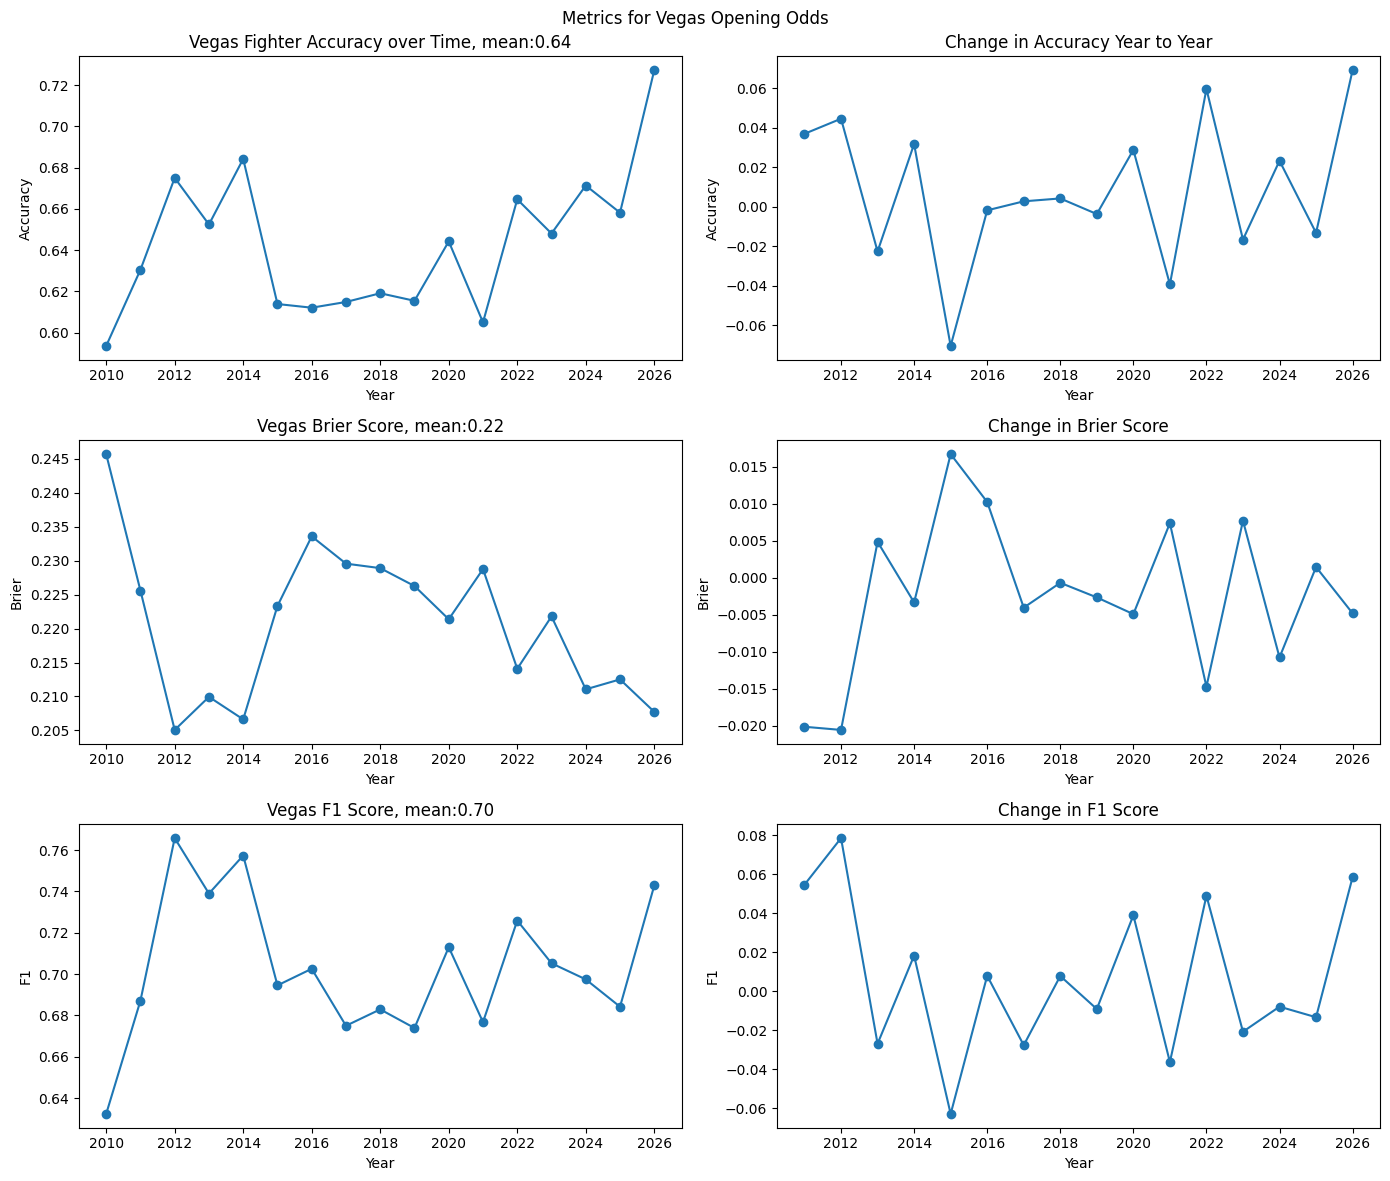

In [6]:
fig, ax = plt.subplots(3, 2, figsize=(14, 12))

metrics = [
    ('accuracy', 'Vegas Fighter Accuracy over Time', 'Change in Accuracy Year to Year'),
    ('brier', 'Vegas Brier Score', 'Change in Brier Score'),
    ('f1', 'Vegas F1 Score', 'Change in F1 Score')
]

for i, (metric, t1, t2) in enumerate(metrics):
    plot_vegas_acc(ax[i], df_vegas, 'open',
                   acc_type=metric,
                   title1=t1,
                   title2=t2)

fig.suptitle('Metrics for Vegas Opening Odds')
plt.tight_layout()
plt.savefig(r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\open_vegas_metrics.png", dpi=300, bbox_inches="tight")



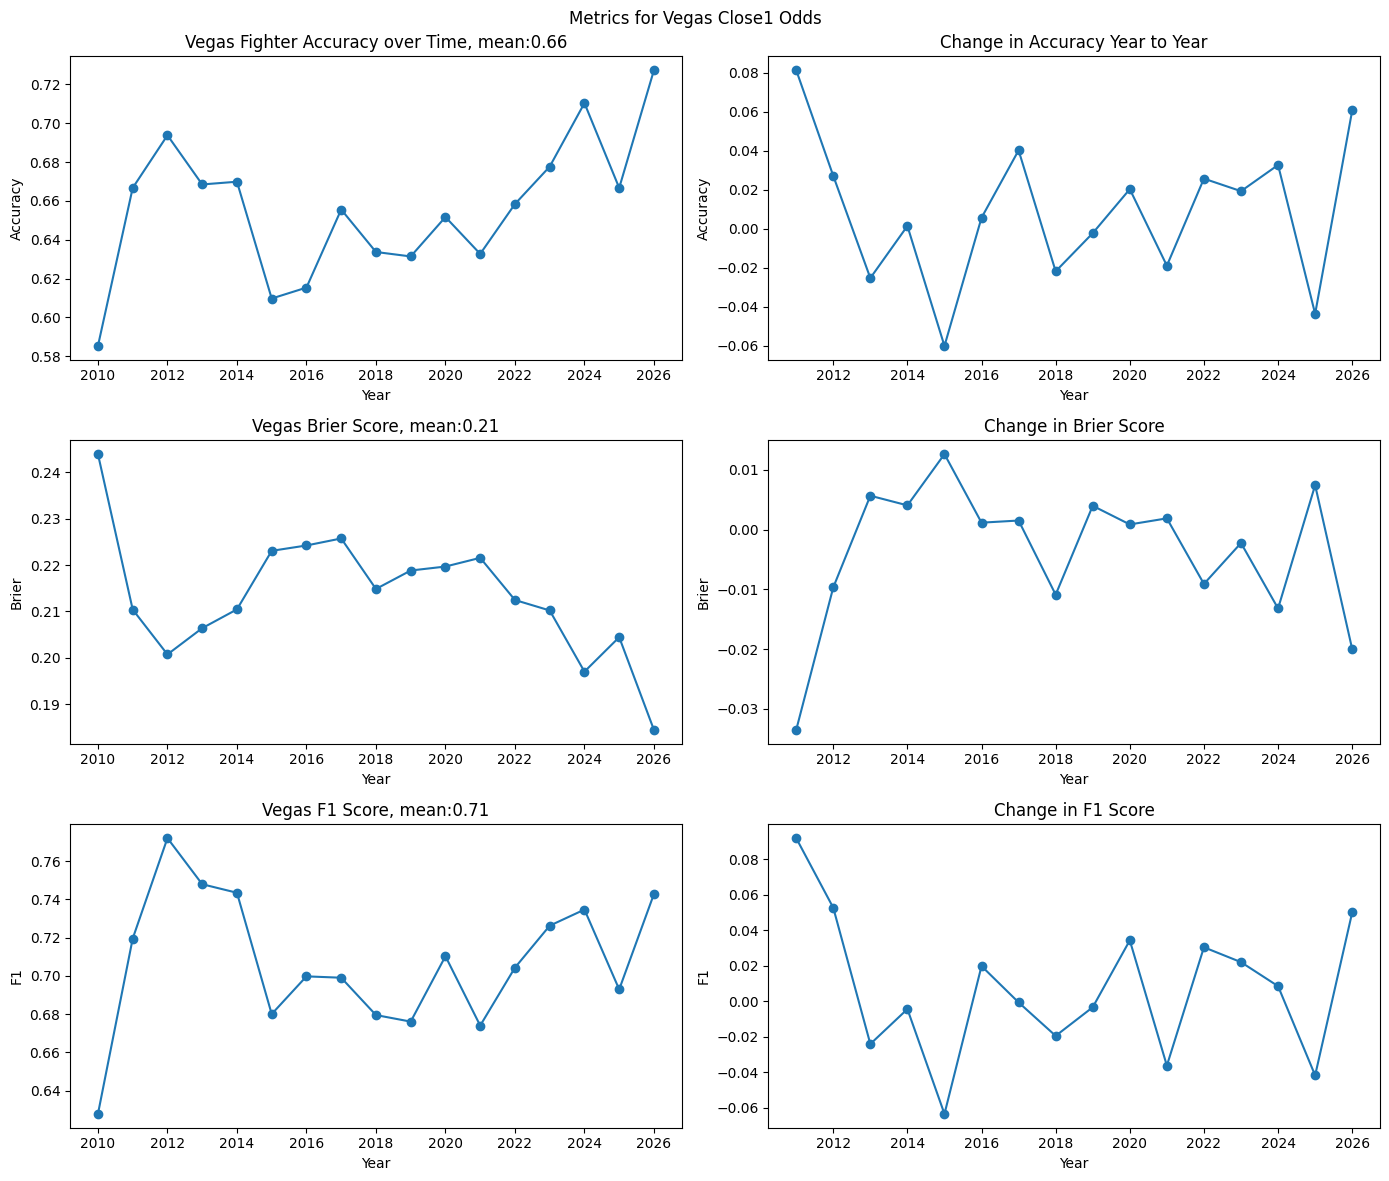

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(14,12))
for i, (metric, t1, t2) in enumerate(metrics):
    plot_vegas_acc(ax[i], df_vegas, 'close1',
                   acc_type=metric,
                   title1=t1,
                   title2=t2)

fig.suptitle('Metrics for Vegas Close1 Odds')
plt.tight_layout()

plt.savefig(r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_vegas_metrics.png", dpi=300, bbox_inches="tight")


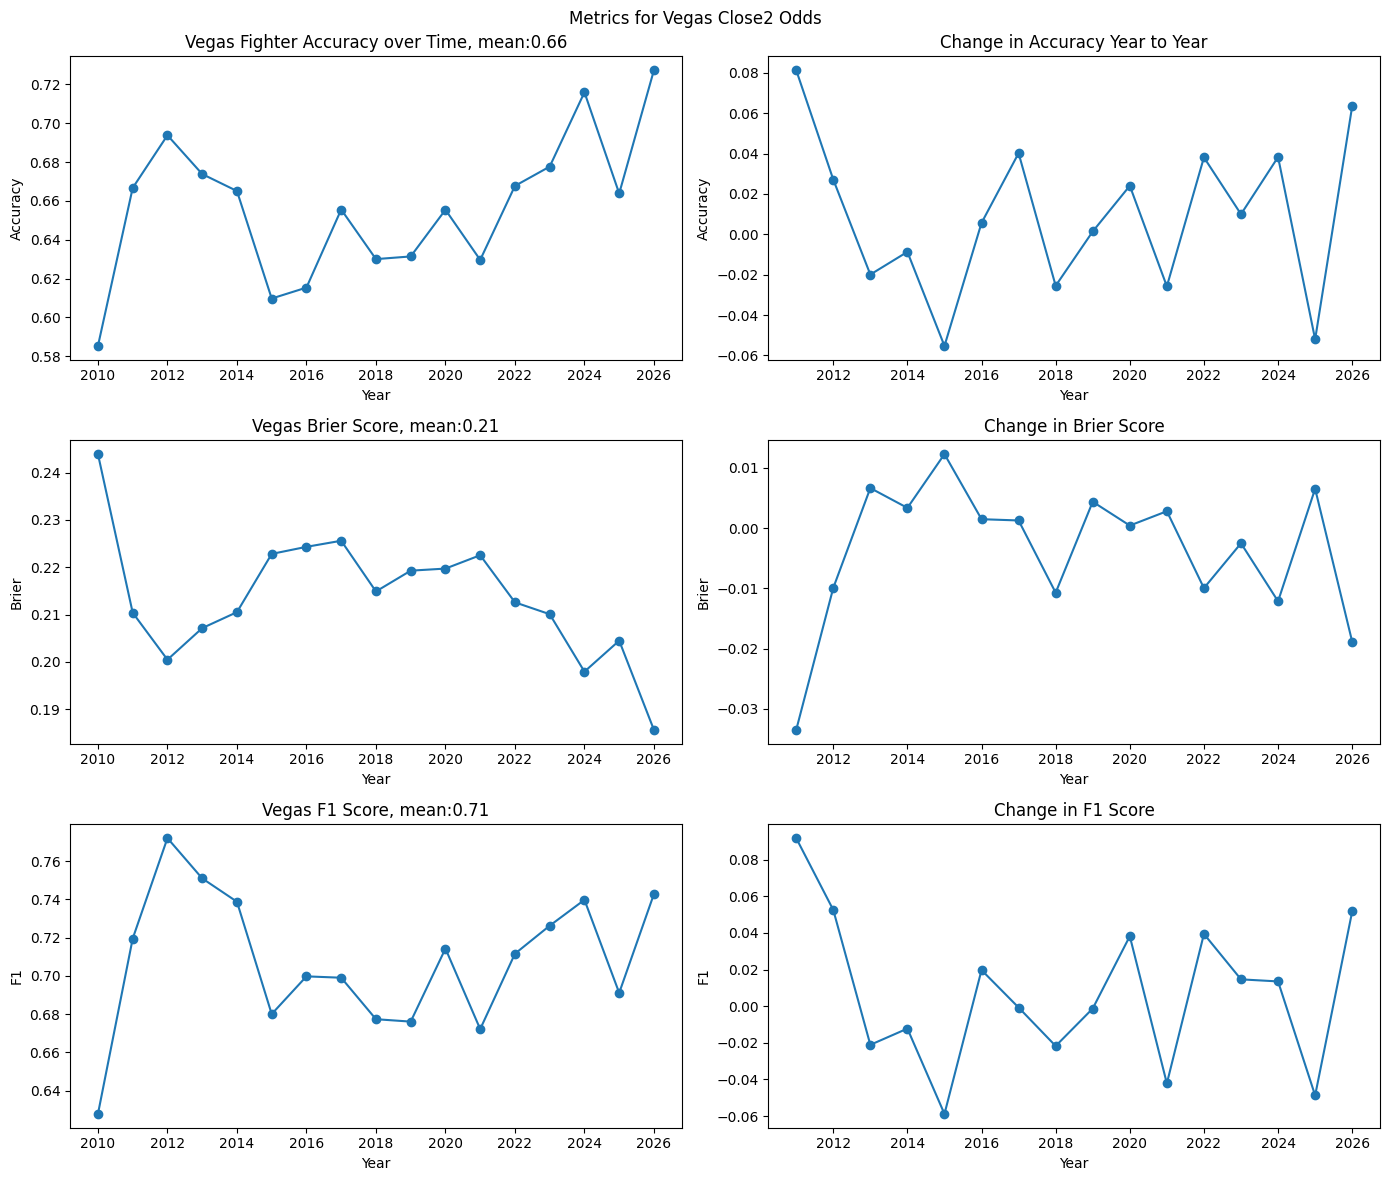

In [8]:
fig, ax = plt.subplots(3, 2, figsize=(14,12))
for i, (metric, t1, t2) in enumerate(metrics):
    plot_vegas_acc(ax[i], df_vegas, 'close2',
                   acc_type=metric,
                   title1=t1,
                   title2=t2)

fig.suptitle('Metrics for Vegas Close2 Odds')
plt.tight_layout()

plt.savefig(r"C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close2_vegas_metrics.png", dpi=300, bbox_inches="tight")
